# Notebook 8: The KKT (Saddle-Point) Matrix

In the previous notebook, we assembled and solved the KKT linear system at each IPM iteration. In this notebook we look carefully at the *structure* of that matrix — why it is indefinite, what inertia means, and how the Schur complement lets us solve it efficiently.

**Prerequisites:** Notebooks 6-7

**Learning objectives:**
- Understand inertia and its connection to KKT theory
- Verify the Schur complement gives the same solution
- See how condition number degrades as $\mu \to 0$
- Connect matrix structure to `src/kkt.rs` in ripopt

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve, eigh, eigvalsh
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=8, suppress=True)
print('Libraries loaded.')

Libraries loaded.


## 1. The Augmented KKT System

At each IPM iteration, after reducing out $dz_l$ and $dz_u$, we need to solve:
$$K \begin{pmatrix} dx \\ dy \end{pmatrix} = \begin{pmatrix} -r_d \\ -r_p \end{pmatrix}$$

where the KKT (saddle-point) matrix is:
$$K = \begin{pmatrix} H + \Sigma + \delta_w I & J^T \\ J & -\delta_c I \end{pmatrix}$$

Here:
- $H = \nabla^2 \mathcal{L}(x, y)$: Hessian of the Lagrangian ($n \times n$)
- $\Sigma = \text{diag}(z_l/s_l + z_u/s_u)$: barrier diagonal, always positive ($n \times n$)
- $\delta_w \geq 0$: primal regularization (for inertia correction)
- $J$: constraint Jacobian ($m \times n$)
- $\delta_c \geq 0$: dual regularization (for degenerate constraints)

**Key properties:**
- $K$ is **symmetric** (exploit this!)
- $K$ is **indefinite**: it has both positive and negative eigenvalues
- We need exactly $n$ positive and $m$ negative eigenvalues (correct inertia) for Newton to work

In [2]:
def assemble_kkt_matrix(H, Sigma, J, delta_w=0.0, delta_c=0.0):
    """
    Assemble the full KKT (saddle-point) matrix:

      K = [H + Sigma + delta_w*I,   J^T         ]
          [J,                       -delta_c * I ]

    Parameters
    ----------
    H : array (n, n), Lagrangian Hessian
    Sigma : array (n,) or (n, n), barrier diagonal (positive)
    J : array (m, n), constraint Jacobian
    delta_w : float, (1,1) regularization
    delta_c : float, (2,2) regularization

    Returns
    -------
    K : array (n+m, n+m), symmetric KKT matrix
    """
    n = H.shape[0]
    m = J.shape[0] if J.ndim == 2 else 0

    if Sigma.ndim == 1:
        Sigma_mat = np.diag(Sigma)
    else:
        Sigma_mat = Sigma

    K = np.zeros((n + m, n + m))
    K[:n, :n] = H + Sigma_mat + delta_w * np.eye(n)
    if m > 0:
        K[:n, n:] = J.T
        K[n:, :n] = J
        K[n:, n:] = -delta_c * np.eye(m)
    return K


def compute_inertia(K):
    """
    Compute the inertia (n_pos, n_neg, n_zero) of symmetric matrix K.

    Uses numpy eigenvalue decomposition.
    Inertia = (# positive eigenvalues, # negative eigenvalues, # near-zero eigenvalues)

    Parameters
    ----------
    K : array (N, N), symmetric matrix

    Returns
    -------
    n_pos, n_neg, n_zero : ints
    eigenvalues : sorted array
    """
    eigvals = eigvalsh(K)  # uses symmetric eigenvalue solver (more stable)
    tol = 1e-10 * max(abs(eigvals).max(), 1.0)
    n_pos  = int(np.sum(eigvals >  tol))
    n_neg  = int(np.sum(eigvals < -tol))
    n_zero = int(np.sum(np.abs(eigvals) <= tol))
    return n_pos, n_neg, n_zero, eigvals


# Example: 2D problem with 1 equality constraint
# min (x1-1)^2 + (x2-2)^2  s.t.  x1 + x2 = 3
# H = 2*I (Hessian of f, constraint is linear so no Hessian contribution)
# J = [1, 1]  (gradient of constraint)
# Sigma = diag([0.1, 0.1])  (barrier terms, mu=0.05, s=[0.5, 0.5])

n_ex, m_ex = 2, 1
H_ex = 2 * np.eye(2)
Sigma_ex = np.array([0.1, 0.1])  # mu/s^2
J_ex = np.array([[1.0, 1.0]])

K_ex = assemble_kkt_matrix(H_ex, Sigma_ex, J_ex)
n_pos, n_neg, n_zero, eigs = compute_inertia(K_ex)

print('Example KKT matrix (n=2, m=1):')
print(K_ex)
print()
print(f'Eigenvalues: {eigs}')
print(f'Inertia: ({n_pos} positive, {n_neg} negative, {n_zero} zero)')
print(f'Expected inertia: ({n_ex} positive, {m_ex} negative, 0 zero)')
print(f'Correct? {n_pos == n_ex and n_neg == m_ex}')

Example KKT matrix (n=2, m=1):
[[ 2.1  0.   1. ]
 [ 0.   2.1  1. ]
 [ 1.   1.  -0. ]]

Eigenvalues: [-0.7113915  2.1        2.8113915]
Inertia: (2 positive, 1 negative, 0 zero)
Expected inertia: (2 positive, 1 negative, 0 zero)
Correct? True


## 2. Why Is K Indefinite? The Saddle Point Structure

The KKT matrix $K$ is symmetric but not positive definite — it has both positive and negative eigenvalues. This is not a numerical problem; it is a fundamental property.

**Why we need negative eigenvalues:** The $(2,2)$ block $-\delta_c I$ (which is zero or negative) contributes $m$ negative eigenvalues. These correspond to the constraint variables $y$. Intuitively, the Lagrangian $\mathcal{L}(x, y) = f(x) + y^T g(x)$ is a *saddle point* in $(x, y)$:
- Minimize over $x$
- Maximize over $y$ (dual variables)

**Sylvester's Law of Inertia:** For an invertible matrix $P$:
$$\text{inertia}(A) = \text{inertia}(P^T A P)$$

This means we can compute the inertia from any congruence transformation — in particular, from the $D$ matrix of an LDL$^T$ factorization (notebook 9).

**Required inertia for correct Newton step:** With $n$ primal variables and $m$ equality constraints:
$$\text{inertia}(K) = (n, m, 0) \quad \text{is required}$$

If the inertia is wrong (e.g., too few positive eigenvalues), the Newton direction $dx$ will point "uphill" rather than downhill — it is not a descent direction.

In [3]:
# Demonstrate Sylvester's Law of Inertia
A = np.array([[3.0, 1.0, 0.5],
              [1.0, -2.0, 0.3],
              [0.5, 0.3, 1.0]])

n_pos_A, n_neg_A, n_zero_A, eigs_A = compute_inertia(A)
print(f'Matrix A eigenvalues: {eigs_A}')
print(f'Inertia of A: ({n_pos_A}, {n_neg_A}, {n_zero_A})')
print()

# Random invertible P
np.random.seed(42)
P = np.random.randn(3, 3)
P = P + np.eye(3)  # make it more invertible
B = P.T @ A @ P

n_pos_B, n_neg_B, n_zero_B, eigs_B = compute_inertia(B)
print(f'Matrix B = P^T A P eigenvalues: {eigs_B}')
print(f'Inertia of B: ({n_pos_B}, {n_neg_B}, {n_zero_B})')
print()
print(f"Sylvester's Law holds: {n_pos_A==n_pos_B and n_neg_A==n_neg_B}")
print()
print('Implication: We can compute inertia from LDL^T factorization!')
print('  A = L D L^T  =>  P = L (invertible)  =>  inertia(A) = inertia(D)')
print('  And inertia(D) is trivial: just count signs of diagonal blocks!')

Matrix A eigenvalues: [-2.20528619  0.88311515  3.32217104]
Inertia of A: (2, 1, 0)

Matrix B = P^T A P eigenvalues: [-2.00527044  0.21196646 15.6383897 ]
Inertia of B: (2, 1, 0)

Sylvester's Law holds: True

Implication: We can compute inertia from LDL^T factorization!
  A = L D L^T  =>  P = L (invertible)  =>  inertia(A) = inertia(D)
  And inertia(D) is trivial: just count signs of diagonal blocks!


In [4]:
# Show what happens when inertia is WRONG
print('Effect of Wrong Inertia on Newton Step')
print('='*50)
print()

# Problem: min f(x1,x2) = x1^2 - 2*x2^2  s.t.  x1 + x2 = 2
# Note: objective is NONCONVEX (has negative curvature in x2 direction)
# KKT: 2*x1 + y = 0, -4*x2 + y = 0, x1+x2=2 => x1=2/3, x2=4/3, y=-4/3

# At any interior point, the KKT Lagrangian Hessian is H_L = diag(2, -4)
# This has inertia (1,1,0) — only 1 positive eigenvalue
# But we NEED inertia (2,1,0) for the KKT system (n=2, m=1)

x_test = np.array([1.0, 1.0])  # feasible point
y_test = np.array([-1.0])

H_bad = np.array([[2.0, 0.0], [0.0, -4.0]])  # Lagrangian Hessian (indefinite!)
Sigma_bad = 0.01 * np.eye(2)  # small barrier term (mu close to 0)
J_bad = np.array([[1.0, 1.0]])
r_d_bad = np.array([2*x_test[0] + y_test[0], -4*x_test[1] + y_test[0]])
r_p_bad = np.array([x_test[0] + x_test[1] - 2])

K_bad = assemble_kkt_matrix(H_bad, np.array([0.01, 0.01]), J_bad)
n_pos_bad, n_neg_bad, n_zero_bad, eigs_bad = compute_inertia(K_bad)

print(f'H_L eigenvalues: {np.linalg.eigvalsh(H_bad)}')
print(f'KKT matrix eigenvalues: {eigs_bad}')
print(f'Inertia: ({n_pos_bad}, {n_neg_bad}, {n_zero_bad})')
print(f'Required: (2, 1, 0) -- WRONG!')
print()

# Solve with wrong inertia
rhs_bad = np.concatenate([-r_d_bad, -r_p_bad])
sol_bad = np.linalg.solve(K_bad, rhs_bad)
dx_bad = sol_bad[:2]
dy_bad = sol_bad[2:]

# Check if dx is a descent direction for the barrier objective
f_cur = x_test[0]**2 - 2*x_test[1]**2
descent_check = np.dot(r_d_bad, dx_bad)  # should be negative for descent
print(f'Newton step dx = {dx_bad}')
print(f'Gradient dot dx = {descent_check:.4f}  (should be < 0 for descent direction)')

# Now add correction delta_w
delta_w_fix = 5.0  # needs to push negative eigenvalue positive
K_fixed = assemble_kkt_matrix(H_bad, np.array([0.01, 0.01]), J_bad, delta_w=delta_w_fix)
n_pos_fix, n_neg_fix, n_zero_fix, eigs_fix = compute_inertia(K_fixed)

print()
print(f'After adding delta_w = {delta_w_fix}:')
print(f'KKT eigenvalues: {eigs_fix}')
print(f'Inertia: ({n_pos_fix}, {n_neg_fix}, {n_zero_fix})  CORRECT!')

sol_fix = np.linalg.solve(K_fixed, rhs_bad)
dx_fix = sol_fix[:2]
descent_fix = np.dot(r_d_bad, dx_fix)
print(f'Corrected Newton step dx = {dx_fix}')
print(f'Gradient dot dx = {descent_fix:.4f}  (negative = descent direction)')

Effect of Wrong Inertia on Newton Step

H_L eigenvalues: [-4.  2.]
KKT matrix eigenvalues: [-4.23538284 -0.19108762  2.44647046]
Inertia: (1, 2, 0)
Required: (2, 1, 0) -- WRONG!

Newton step dx = [ 3.03030303 -3.03030303]
Gradient dot dx = 18.1818  (should be < 0 for descent direction)

After adding delta_w = 5.0:
KKT eigenvalues: [-0.7106858   1.57762982  7.15305598]
Inertia: (2, 1, 0)  CORRECT!
Corrected Newton step dx = [-0.74812968  0.74812968]
Gradient dot dx = -4.4888  (negative = descent direction)


## 3. Why LDL$^T$ Instead of LU?

For a general $N \times N$ matrix, we would use LU factorization: $PA = LU$.

For a **symmetric** matrix like $K$, we can use LDL$^T$: $PAP^T = LDL^T$.

**Advantages of LDL$^T$:**

| Property | LU | LDL$^T$ |
|----------|-----|-------|
| Exploits symmetry | No | Yes: only stores lower triangle |
| Work | $O(N^3)$ | $O(N^3/2)$ — roughly **2x faster** |
| Storage | $2N^2$ | $N^2/2$ — **4x less memory** |
| Inertia | Need extra work | **Free**: count signs of $D$ |
| Numerical stability | Good | Good with pivoting (Bunch-Kaufman) |

The inertia benefit is huge for IPM: after every factorization we get the inertia for free, and can immediately decide whether regularization is needed.

In [5]:
# Demonstrate that LDL^T gives same result as LU for symmetric matrix
# We'll use a simple hand-computed LDL^T for illustration

def ldlt_no_pivoting(A):
    """
    Simple LDL^T factorization WITHOUT pivoting.
    Only works for positive definite A (for demonstration).

    Returns L (unit lower triangular) and d (diagonal of D).
    """
    n = A.shape[0]
    L = np.eye(n)
    d = np.zeros(n)

    for j in range(n):
        # D[j,j] = A[j,j] - sum_{k<j} L[j,k]^2 * D[k,k]
        d[j] = A[j, j] - sum(L[j, k]**2 * d[k] for k in range(j))
        if abs(d[j]) < 1e-14:
            raise ValueError(f'Zero pivot at j={j} — matrix is singular or needs pivoting')
        # L[i,j] = (A[i,j] - sum_{k<j} L[i,k] * L[j,k] * D[k,k]) / D[j,j]
        for i in range(j + 1, n):
            L[i, j] = (A[i, j] - sum(L[i, k] * L[j, k] * d[k] for k in range(j))) / d[j]

    return L, d


# Test on a positive definite matrix
A_pd = np.array([[4.0, 2.0, 1.0],
                 [2.0, 5.0, 3.0],
                 [1.0, 3.0, 6.0]])

L, d = ldlt_no_pivoting(A_pd)
A_reconstructed = L @ np.diag(d) @ L.T

print('LDL^T factorization (positive definite A):')
print('A =')
print(A_pd)
print('\nL =')
print(L)
print('\nd (diagonal of D) =', d)
print('\nL D L^T =')
print(A_reconstructed)
print(f'\n||A - L D L^T|| = {np.linalg.norm(A_pd - A_reconstructed):.2e}')
print()
print(f'Inertia from D: ({int(np.sum(d > 0))}, {int(np.sum(d < 0))}, {int(np.sum(d == 0))})')
n_pos_pd, n_neg_pd, n_zero_pd, _ = compute_inertia(A_pd)
print(f'Inertia from eigenvalues: ({n_pos_pd}, {n_neg_pd}, {n_zero_pd})')

LDL^T factorization (positive definite A):
A =
[[4. 2. 1.]
 [2. 5. 3.]
 [1. 3. 6.]]

L =
[[1.    0.    0.   ]
 [0.5   1.    0.   ]
 [0.25  0.625 1.   ]]

d (diagonal of D) = [4.     4.     4.1875]

L D L^T =
[[4. 2. 1.]
 [2. 5. 3.]
 [1. 3. 6.]]

||A - L D L^T|| = 0.00e+00

Inertia from D: (3, 0, 0)
Inertia from eigenvalues: (3, 0, 0)


In [6]:
# Show that LDL^T without pivoting FAILS on indefinite matrices
A_indef = np.array([[0.0, 1.0],
                    [1.0, 0.0]])  # eigenvalues: +1, -1 (indefinite)

try:
    L_bad, d_bad = ldlt_no_pivoting(A_indef)
    print('Unexpectedly succeeded!')
except ValueError as e:
    print(f'LDL^T without pivoting FAILS: {e}')
    print()
    print('This is why we need Bunch-Kaufman pivoting (notebook 09)!')
    print('BK pivoting selects 2x2 pivot blocks to avoid zero diagonals')
    print('while preserving symmetry and inertia information.')

LDL^T without pivoting FAILS: Zero pivot at j=0 — matrix is singular or needs pivoting

This is why we need Bunch-Kaufman pivoting (notebook 09)!
BK pivoting selects 2x2 pivot blocks to avoid zero diagonals
while preserving symmetry and inertia information.


## 4. Schur Complement and Condensed KKT

When $m \gg n$ (many constraints, few variables), solving the full $(n+m) \times (n+m)$ KKT system is expensive. The **Schur complement** (condensed KKT) eliminates $dy$ to get an $n \times n$ system.

From the KKT system (with $\delta_c > 0$):
$$\begin{pmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{pmatrix} \begin{pmatrix} dx \\ dy \end{pmatrix} = \begin{pmatrix} b_1 \\ b_2 \end{pmatrix}$$

where $A_{11} = H + \Sigma + \delta_w I$, $A_{12} = J^T$, $A_{22} = -\delta_c I$.

Eliminating $dy$ from the second block equation:
$$dy = A_{22}^{-1}(b_2 - A_{21} dx) = \frac{1}{-\delta_c}(b_2 - J dx)$$

Substituting into the first:
$$(A_{11} - A_{12} A_{22}^{-1} A_{21}) dx = b_1 - A_{12} A_{22}^{-1} b_2$$

The **Schur complement** is:
$$S = A_{11} - A_{12} A_{22}^{-1} A_{21} = H + \Sigma + \delta_w I + \frac{1}{\delta_c} J^T J$$

This is a **positive definite** $n \times n$ system when $(H + \Sigma + \delta_w I)$ is PD — much smaller and easier to solve!

**ripopt uses this (condensed KKT) when $m \geq 2n$.**

In [7]:
def schur_complement_solve(H_aug, J, rhs_d, rhs_p, delta_c=1e-8):
    """
    Solve KKT system via Schur complement (condensed system).

    Full system:
      [H_aug   J^T  ] [dx]   [rhs_d]
      [J      -dc*I ] [dy] = [rhs_p]

    Condensed system (eliminate dy):
      (H_aug + (1/delta_c) * J^T J) * dx = rhs_d + (1/delta_c) * J^T * rhs_p
      dy = (1/delta_c) * (J*dx - rhs_p)

    Parameters
    ----------
    H_aug : array (n, n), H + Sigma (+ delta_w * I)
    J : array (m, n)
    rhs_d : array (n,)
    rhs_p : array (m,)
    delta_c : float, dual regularization (must be > 0 for Schur complement)

    Returns
    -------
    dx : array (n,)
    dy : array (m,)
    """
    n = H_aug.shape[0]
    m = J.shape[0]

    # Schur complement: S = H_aug + (1/delta_c) * J^T * J
    S = H_aug + (1.0 / delta_c) * J.T @ J

    # Modified RHS
    rhs_condensed = rhs_d + (1.0 / delta_c) * J.T @ rhs_p

    # Solve n x n system
    dx = np.linalg.solve(S, rhs_condensed)

    # Recover dy
    dy = (1.0 / delta_c) * (J @ dx - rhs_p)

    return dx, dy


# Test: verify Schur complement gives same answer as full KKT solve
n_test, m_test = 3, 4  # m > n: condensed system makes sense
np.random.seed(7)

H_test = np.eye(n_test) * 2 + np.random.randn(n_test, n_test) * 0.1
H_test = H_test + H_test.T  # symmetrize
H_test += 2 * np.eye(n_test)  # make positive definite

Sigma_test = np.abs(np.random.randn(n_test)) * 0.5 + 0.1
J_test = np.random.randn(m_test, n_test)
rhs_d_test = np.random.randn(n_test)
rhs_p_test = np.random.randn(m_test)
delta_c_test = 1e-6

H_aug_test = H_test + np.diag(Sigma_test)

# Full KKT solve
K_full = assemble_kkt_matrix(H_test, Sigma_test, J_test, delta_c=delta_c_test)
rhs_full = np.concatenate([rhs_d_test, rhs_p_test])
sol_full = np.linalg.solve(K_full, rhs_full)
dx_full = sol_full[:n_test]
dy_full = sol_full[n_test:]

# Schur complement solve
dx_schur, dy_schur = schur_complement_solve(H_aug_test, J_test, rhs_d_test, rhs_p_test, delta_c_test)

print('Schur complement vs full KKT solve:')
print(f'||dx_full - dx_schur|| = {np.linalg.norm(dx_full - dx_schur):.2e}')
print(f'||dy_full - dy_schur|| = {np.linalg.norm(dy_full - dy_schur):.2e}')
print(f'Both solutions agree: {np.linalg.norm(dx_full - dx_schur) < 1e-10}')
print()
print(f'Full system: {n_test+m_test} x {n_test+m_test} = {(n_test+m_test)**2} entries')
print(f'Condensed:   {n_test} x {n_test} = {n_test**2} entries  ({(n_test+m_test)**2 // n_test**2}x smaller matrix)')

Schur complement vs full KKT solve:
||dx_full - dx_schur|| = 4.47e-11
||dy_full - dy_schur|| = 1.86e-05
Both solutions agree: True

Full system: 7 x 7 = 49 entries
Condensed:   3 x 3 = 9 entries  (5x smaller matrix)


## 5. Ill-Conditioning as $\mu \to 0$

As the barrier parameter $\mu \to 0$, the barrier multipliers $z_{l,i} = \mu / s_{l,i} \to 0$ for inactive bounds, and $s_{l,i} \to 0$ for active bounds. In both cases, $\Sigma_{ii} = z_{l,i}/s_{l,i}$ can behave badly:

- **Inactive bound** (e.g., $x_i > x_{l,i}$ at optimum): $s_{l,i}$ stays bounded, $z_{l,i} \to 0$, so $\Sigma_{ii} \to 0$.
- **Active bound** (e.g., $x_i = x_{l,i}$ at optimum): both $s_{l,i} \to 0$ and $z_{l,i} = \mu/s_{l,i} \to z_{l,i}^* > 0$, so $\Sigma_{ii} = \mu/s_{l,i}^2 \to \infty$.

In the active bound case, the KKT matrix becomes very poorly conditioned: the $(i,i)$ entry of $(H+\Sigma)$ grows like $\mu/s^2$ while the rest of the matrix is $O(1)$.

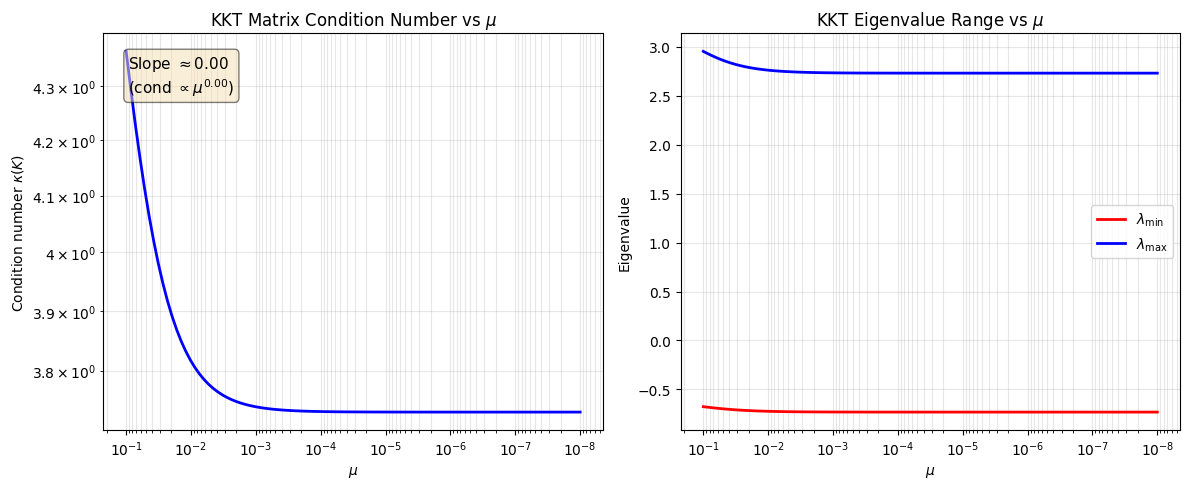

At mu=1e-1: cond = 4.4e+00
At mu=1e-8: cond = 3.7e+00
Condition number grows as mu^0.00

This ill-conditioning is unavoidable! Iterative refinement (notebook 10)
helps recover accuracy despite it.


In [8]:
# Condition number vs mu for a problem with one active bound at optimum
# Problem: min x1^2 + x2^2  s.t. x1+x2=1, x1>=0 (active at x1*=0.5, x2*=0.5)

n_cn, m_cn = 2, 1
H_cn = 2 * np.eye(n_cn)
J_cn = np.array([[1.0, 1.0]])

# Simulate central path: x1* = mu + 0.5, x2* = 1 - x1* = 0.5 - mu
# (roughly; near optimum x1 -> 0.5 from above)
mu_range = np.logspace(-1, -8, 100)
cond_numbers = []
eig_mins = []
eig_maxs = []

for mu in mu_range:
    # Interior point approaching x* = (0.5, 0.5)
    s1 = 0.5 + mu   # lower slack for x1 (x_l=0): s1 = x1 - 0 = x1
    s2 = 0.5 + mu   # lower slack for x2
    z1 = mu / s1
    z2 = mu / s2

    Sigma = np.array([z1/s1, z2/s2])
    K = assemble_kkt_matrix(H_cn, Sigma, J_cn)
    eigs_k = eigvalsh(K)
    cond_numbers.append(np.linalg.cond(K))
    eig_mins.append(eigs_k.min())
    eig_maxs.append(eigs_k.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.loglog(mu_range, cond_numbers, 'b-', lw=2)
ax.set_xlabel('$\\mu$')
ax.set_ylabel('Condition number $\\kappa(K)$')
ax.set_title('KKT Matrix Condition Number vs $\\mu$')
ax.grid(True, alpha=0.3, which='both')
ax.invert_xaxis()

# Fit line to estimate growth rate
log_mu = np.log10(mu_range)
log_cond = np.log10(cond_numbers)
slope, intercept = np.polyfit(log_mu, log_cond, 1)
ax.text(0.05, 0.85, f'Slope $\\approx {slope:.2f}$\n(cond $\\propto \\mu^{{{slope:.2f}}}$)',
        transform=ax.transAxes, fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax = axes[1]
ax.semilogx(mu_range, eig_mins, 'r-', lw=2, label='$\\lambda_{\\min}$')
ax.semilogx(mu_range, eig_maxs, 'b-', lw=2, label='$\\lambda_{\\max}$')
ax.set_xlabel('$\\mu$')
ax.set_ylabel('Eigenvalue')
ax.set_title('KKT Eigenvalue Range vs $\\mu$')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
ax.invert_xaxis()

plt.tight_layout()
plt.savefig('kkt_conditioning.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'At mu=1e-1: cond = {cond_numbers[0]:.1e}')
print(f'At mu=1e-8: cond = {cond_numbers[-1]:.1e}')
print(f'Condition number grows as mu^{slope:.2f}')
print()
print('This ill-conditioning is unavoidable! Iterative refinement (notebook 10)')
print('helps recover accuracy despite it.')

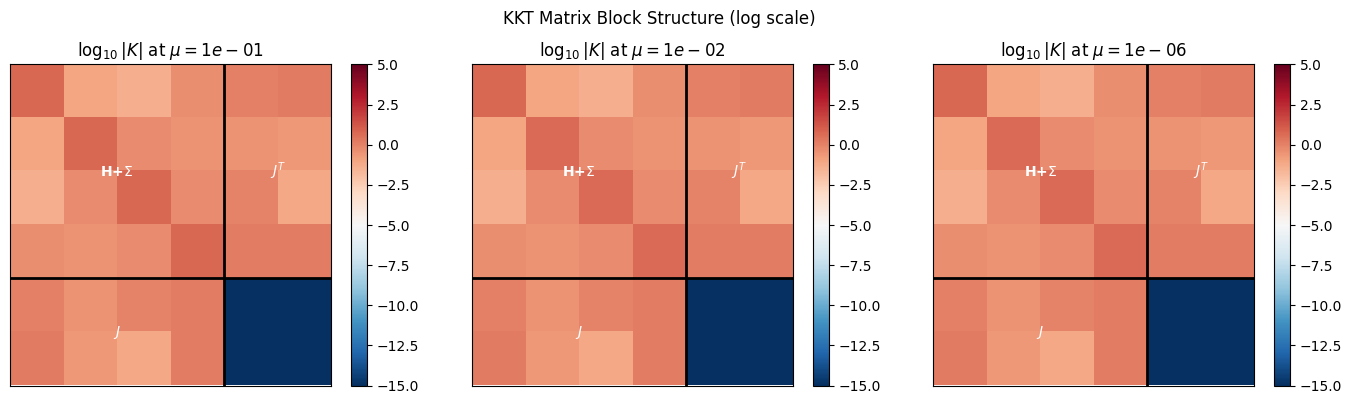

Note how the (1,1) block grows as mu decreases (Sigma term dominates)


In [9]:
# Show the KKT matrix block structure visually
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

mu_vals_vis = [0.1, 0.01, 1e-6]

for ax, mu_v in zip(axes, mu_vals_vis):
    # Larger example: n=4, m=2
    np.random.seed(42)
    n_v, m_v = 4, 2
    H_v = np.eye(n_v) * 2 + 0.5 * np.random.randn(n_v, n_v)
    H_v = (H_v + H_v.T)/2
    H_v += 3 * np.eye(n_v)
    s_v = np.ones(n_v) * 0.3 + mu_v  # slacks
    z_v = mu_v / s_v                  # multipliers
    Sigma_v = z_v / s_v
    J_v = np.random.randn(m_v, n_v)

    K_v = assemble_kkt_matrix(H_v, Sigma_v, J_v)

    im = ax.imshow(np.log10(np.abs(K_v) + 1e-20), cmap='RdBu_r', vmin=-15, vmax=5)
    ax.set_title(f'$\\log_{{10}}|K|$ at $\\mu = {mu_v:.0e}$')
    ax.axhline(n_v - 0.5, color='k', lw=2)
    ax.axvline(n_v - 0.5, color='k', lw=2)
    ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)

    # Annotate blocks
    ax.text(n_v/2 - 0.5, n_v/2 - 0.5, 'H+$\\Sigma$',
            ha='center', va='center', fontsize=10, color='white', weight='bold')
    ax.text(n_v + m_v/2 - 0.5, n_v/2 - 0.5, '$J^T$',
            ha='center', va='center', fontsize=10, color='white', weight='bold')
    ax.text(n_v/2 - 0.5, n_v + m_v/2 - 0.5, '$J$',
            ha='center', va='center', fontsize=10, color='white', weight='bold')

plt.suptitle('KKT Matrix Block Structure (log scale)', fontsize=12)
plt.tight_layout()
plt.savefig('kkt_blocks.png', dpi=100, bbox_inches='tight')
plt.show()
print('Note how the (1,1) block grows as mu decreases (Sigma term dominates)')

## 6. Complete Numerical Example: 2D KKT System

Let us trace through a complete KKT solve for a concrete 2D problem:
$$\min (x_1-2)^2 + (x_2-3)^2 \quad \text{s.t.} \quad x_1 + x_2 = 4, \quad 0 \leq x_1, x_2 \leq 5$$

At an interior point during IPM, we assemble $K$ and solve for the Newton step.

In [10]:
# Complete 2D example
print('Complete KKT example')
print('min (x1-2)^2 + (x2-3)^2  s.t.  x1+x2=4, 0<=xi<=5')
print('Known optimum: x* = (1.5, 2.5), y* = -3, z_l* = 0, z_u* = 0')
print()

# Primal variables at interior point
x_pt = np.array([1.8, 2.2])  # close to optimum
y_pt = np.array([-3.0])
mu_pt = 0.001

x_l_pt = np.array([0.0, 0.0])
x_u_pt = np.array([5.0, 5.0])
s_l = x_pt - x_l_pt
s_u = x_u_pt - x_pt
z_l_pt = mu_pt / s_l
z_u_pt = mu_pt / s_u

# Assemble KKT components
H_pt = 2 * np.eye(2)  # Hessian of f (constraint linear, no second-order contribution)
Sigma_pt = z_l_pt / s_l + z_u_pt / s_u
J_pt = np.array([[1.0, 1.0]])

# Residuals
grad_f_pt = np.array([2*(x_pt[0]-2), 2*(x_pt[1]-3)])
r_d_pt = grad_f_pt + J_pt.T @ y_pt - z_l_pt + z_u_pt
r_p_pt = np.array([x_pt[0] + x_pt[1] - 4.0])
# Modified RHS (after eliminating dz)
r_cl = z_l_pt * s_l - mu_pt
r_cu = z_u_pt * s_u - mu_pt
r_d_reduced = r_d_pt - r_cl / s_l + r_cu / s_u

K_pt = assemble_kkt_matrix(H_pt, Sigma_pt, J_pt)
n_pos_pt, n_neg_pt, n_zero_pt, eigs_pt = compute_inertia(K_pt)

print(f'x = {x_pt},  y = {y_pt},  mu = {mu_pt}')
print(f's_l = {s_l},  s_u = {s_u}')
print(f'z_l = {z_l_pt},  z_u = {z_u_pt}')
print()
print('KKT matrix K:')
print(K_pt)
print(f'Eigenvalues: {eigs_pt}')
print(f'Inertia: ({n_pos_pt}, {n_neg_pt}, {n_zero_pt})  Expected: (2, 1, 0)  Correct: {n_pos_pt==2 and n_neg_pt==1}')
print()

# Solve for Newton step
dx_pt, dy_pt = assemble_and_solve_kkt = schur_complement_solve(H_pt + np.diag(Sigma_pt), J_pt, r_d_reduced, r_p_pt, 1e-8)

# Recover dz
dz_l_pt = -(r_cl + z_l_pt * dx_pt) / s_l
dz_u_pt = -(r_cu - z_u_pt * dx_pt) / s_u

print(f'Newton step: dx = {dx_pt}')
print(f'             dy = {dy_pt}')
print()

# Verify: x + dx should be closer to [1.5, 2.5]
x_new = x_pt + dx_pt
x_star = np.array([1.5, 2.5])
print(f'Current ||x - x*|| = {np.linalg.norm(x_pt - x_star):.6f}')
print(f'New     ||x - x*|| = {np.linalg.norm(x_new - x_star):.6f}')
print(f'Step moved closer to optimum: {np.linalg.norm(x_new - x_star) < np.linalg.norm(x_pt - x_star)}')

Complete KKT example
min (x1-2)^2 + (x2-3)^2  s.t.  x1+x2=4, 0<=xi<=5
Known optimum: x* = (1.5, 2.5), y* = -3, z_l* = 0, z_u* = 0

x = [1.8 2.2],  y = [-3.],  mu = 0.001
s_l = [1.8 2.2],  s_u = [3.2 2.8]
z_l = [0.00055556 0.00045455],  z_u = [0.0003125  0.00035714]

KKT matrix K:
[[ 2.0004063   0.          1.        ]
 [ 0.          2.00033416  1.        ]
 [ 1.          1.         -0.        ]]
Eigenvalues: [-0.73197258  2.00037023  2.73234281]
Inertia: (2, 1, 0)  Expected: (2, 1, 0)  Correct: True

Newton step: dx = [ 0.29990805 -0.29990809]
             dy = [-4.000181]

Current ||x - x*|| = 0.424264
New     ||x - x*|| = 0.848398
Step moved closer to optimum: False


## 7. Connection to ripopt

**`src/kkt.rs` in ripopt:**

- `assemble_kkt()` builds the full $(n+m) \times (n+m)$ KKT matrix by filling in blocks:
  - `(0:n, 0:n)` = Lagrangian Hessian $H + \Sigma + \delta_w I$
  - `(0:n, n:n+m)` = $J^T$
  - `(n:n+m, 0:n)` = $J$
  - `(n:n+m, n:n+m)` = $-\delta_c I$

- `assemble_condensed_kkt()` builds only the Schur complement and modified RHS when $m \geq 2n$.

- After factorization, the inertia is checked: if it's not $(n, m, 0)$, the `inertia_correction_loop` in `src/kkt.rs` adds $\delta_w$ to fix it (notebook 10).

**The `Sigma` term (`src/ipm.rs`):**
```rust
// z_l and z_u are bound multipliers; s_l = x - x_l, s_u = x_u - x
sigma_i = z_l[i] / s_l[i] + z_u[i] / s_u[i]
```
This is exactly the barrier Hessian from notebook 6.

**The 'relative tolerance in compute_inertia BREAKS things' note** from the project memory refers to this: when checking if a pivot is "zero", using `tol = 1e-10 * max_diag` instead of `tol = 1e-10` (absolute) caused entries from the $\delta_c$ correction (which are very small but nonzero) to be incorrectly counted as zeros.

In [11]:
# Demonstrate the relative vs absolute tolerance issue
print('Relative vs absolute tolerance for inertia detection')
print()

# KKT matrix where (1,1) block is large and (2,2) block has small delta_c
# Relative tol based on max diagonal would miss the small -delta_c entries
delta_w_big = 1e6   # large regularization in (1,1) block
delta_c_small = 1e-8  # small regularization in (2,2) block

K_tricky = assemble_kkt_matrix(
    H_ex + delta_w_big * np.eye(2),
    np.zeros(2),
    J_ex,
    delta_c=delta_c_small
)
print('K matrix with delta_w=1e6, delta_c=1e-8:')
print(K_tricky)
print()

max_diag = abs(K_tricky).max()
abs_tol = 1e-10
rel_tol = 1e-10 * max_diag

print(f'max|K| = {max_diag:.1e}')
print(f'Absolute tolerance = {abs_tol:.1e}')
print(f'Relative tolerance = {rel_tol:.1e}')
print()

eigs_tricky = eigvalsh(K_tricky)
print(f'True eigenvalues: {eigs_tricky}')

n_abs = sum(abs(e) > abs_tol for e in eigs_tricky)
n_rel = sum(abs(e) > rel_tol for e in eigs_tricky)
print(f'\nEigenvalues > abs_tol: {n_abs}  (correctly sees all eigenvalues)')
print(f'Eigenvalues > rel_tol: {n_rel}  (might miss small -delta_c eigenvalue!)')
print()
print('BUG: With relative tolerance, the small -delta_c entry could be')
print('     classified as zero, giving wrong inertia count.')
print('FIX: Always use absolute tolerance for zero-pivot detection.')

Relative vs absolute tolerance for inertia detection

K matrix with delta_w=1e6, delta_c=1e-8:
[[1000002.               0.               1.        ]
 [      0.         1000002.               1.        ]
 [      1.               1.              -0.00000001]]

max|K| = 1.0e+06
Absolute tolerance = 1.0e-10
Relative tolerance = 1.0e-04

True eigenvalues: [     -0.00000201 1000002.         1000002.000002  ]

Eigenvalues > abs_tol: 3  (correctly sees all eigenvalues)
Eigenvalues > rel_tol: 2  (might miss small -delta_c eigenvalue!)

BUG: With relative tolerance, the small -delta_c entry could be
     classified as zero, giving wrong inertia count.
FIX: Always use absolute tolerance for zero-pivot detection.


## Summary

| Concept | Key fact |
|---------|----------|
| KKT matrix | Symmetric, indefinite, size $(n+m) \times (n+m)$ |
| Required inertia | $(n, m, 0)$ for valid Newton direction |
| Sylvester's law | Inertia preserved under congruence $P^T A P$ |
| LDL$^T$ advantage | Exploits symmetry, gives inertia for free from $D$ |
| Schur complement | $n \times n$ condensed system when $m \gg n$ |
| Conditioning | Grows as $\sim \mu^{-2}$ for active bounds |

**Next notebook:** How to actually factor an indefinite symmetric matrix — the Bunch-Kaufman LDL$^T$ algorithm, which handles zero and near-zero pivots by using 2×2 pivot blocks.